***<center>Análisis Estratégico del Mercado Global de Videojuegos</center>***

En este proyecto se explora un conjunto de datos históricos de la industria global de videojuegos con el objetivo de identificar los factores que influyen en el éxito comercial de un videojuego. A través del análisis de datos se estudian variables como plataformas, géneros, calificaciones de usuarios y críticos, ventas por región y clasificaciones de contenido.

El proyecto busca descubrir patrones, tendencias y comportamientos del mercado que permitan generar información estratégica para la toma de decisiones, detectar oportunidades de crecimiento y comprender qué características pueden convertir un lanzamiento en un producto exitoso.

Se aplican técnicas de limpieza, exploración y análisis de datos para transformar información histórica en insights accionables, simulando un escenario real de negocio donde una empresa necesita optimizar sus estrategias y campañas futuras.

***Objetivos principales:***
- Explorar tendencias históricas de la industria de videojuegos.
- Identificar variables asociadas al éxito de un videojuego.
- Analizar el comportamiento de ventas por plataforma y región.
- Evaluar la influencia de críticas y clasificaciones en el desempeño comercial.
- Obtener hallazgos basados en datos para apoyar decisiones estratégicas.

## 1. INICIALIZACIÓN

In [13]:
# Cargar todas las librerías
import pandas as pd 
import numpy as np
import math as mt
import seaborn as sns
from scipy import stats as st
from matplotlib import pyplot as plt

## 2. CARGA LOS DATOS

In [14]:
# Carga los archivos de datos en un DataFrame
games = pd.read_csv("games.csv")

## 3. REVISAR LOS DATOS

In [15]:
# Se muestra la informacion de los datos para observar particularidades en los mismos
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [16]:
# Buscamos mediante una muestra aleatoria los datos y de esta manera ver como se comportan
games.head(10)

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


In [17]:
print(games.isna().sum())

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64


Tras una breve exploración y revisión de los datos, se identificó que los nombres de las columnas contienen mayúsculas. Para facilitar su manipulación y evitar posibles errores, lo más adecuado es convertirlos a minúsculas. Asimismo, se detectaron valores ausentes en columnas como "Year_of_Release", "Critic_Score", "User_Score" y "Rating", por lo que resulta fundamental tratarlos correctamente con el fin de evitar interferencias en el análisis posterior de los datos.

## 4 PREPARA LOS DATOS

In [18]:
# Se reemplaza los nombres de las columnas.
games.columns = games.columns.str.lower()

In [19]:
# Se convierte los datos en los tipos necesarios.
games = games.dropna(subset = ["name", "year_of_release", "genre"])
games["year_of_release"] = games["year_of_release"].astype(int)
games["user_score"] = pd.to_numeric(games["user_score"], errors="coerce")

En primer lugar, como se mencionó anteriormente, se cambiaron los nombres de las columnas de mayúsculas a minúsculas con el fin de facilitar su acceso y manipulación. Posteriormente, se eliminaron aquellas filas que no contenían información esencial para el análisis, específicamente en las columnas "name", "year_of_release" y "genre". La ausencia de estos datos dificultaría un análisis adecuado, ya que sin el nombre del juego no sería posible identificarlo, el año de lanzamiento resulta indispensable para estudiar tendencias y el género es clave para realizar procesos de segmentación. Por lo tanto, la eliminación de dichas filas no representa una pérdida significativa para el análisis.

Adicionalmente, se realizaron transformaciones en los tipos de datos. La columna "year_of_release" se convirtió de float a int, con el fin de trabajar de manera más precisa con los años de lanzamiento, teniendo en cuenta que no se cuenta con información sobre el mes ni el día, lo que hacía innecesario un formato DateTime.

En el caso de la columna "user_score", se presentó un reto adicional: además de las calificaciones numéricas, algunas filas contenían la etiqueta "TBD" (to be determined, por determinar). Esta denominación impedía el cambio directo de tipo de datos, ya que no podía interpretarse como un valor numérico. Para resolver este inconveniente, se reemplazaron los valores "TBD" por NaN, considerando que representan efectivamente una ausencia de puntuación. De esta manera, se pudo convertir la columna de object a float, lo cual permite interpretar correctamente las calificaciones otorgadas por los usuarios y realizar cálculos estadísticos sobre estos valores.

## 4.1 Explicación del por qué se relleno los valores ausentes.

En cuanto al manejo de los valores ausentes, y teniendo en cuenta lo explicado anteriormente, la opción más viable fue eliminar aquellas filas que no aportaban información relevante al análisis y que solo generaban incertidumbre. Por ejemplo, en la columna "year_of_release" hubiera sido posible rellenar los valores vacíos con la media o la mediana; sin embargo, esto introduciría información errónea, ya que no correspondería a un año real de lanzamiento, sino a un valor aproximado que restaría veracidad a los datos.

Por otro lado, en las columnas "critic_score", "user_score" y "rating", tampoco resultaba adecuado realizar un relleno. Sustituir los valores ausentes por un 0.0 podría interpretarse como una calificación negativa, lo cual distorsionaría la percepción del juego tanto desde la crítica como desde la opinión de los usuarios. En el caso de "rating", tampoco es válido asumir que un juego carece de clasificación, ya que es bien sabido que todo videojuego, antes de su lanzamiento, debe contar con una etiqueta que indique el público objetivo al que va dirigido (mayores de edad, menores o todo público).

Por lo tanto, la decisión más adecuada fue mantener los valores ausentes en estas columnas, ya que no representan un obstáculo significativo para el análisis y permiten conservar la integridad de los datos sin introducir supuestos incorrectos.

## 4.2 ¿Por qué los valores están ausentes?

En cuanto a las posibles causas de los valores ausentes, estas pueden explicarse desde dos perspectivas: interna y externa.

A nivel interno, es posible que la base de datos haya experimentado fallas durante su carga, lo que pudo ocasionar la pérdida parcial de la información. Otra posibilidad es que la persona responsable de registrar o subir los datos haya cometido algún error en el proceso, generando inconsistencias o vacíos. Asimismo, puede suceder que, al momento de recopilar la información, ciertos campos aún no estuvieran disponibles, como por ejemplo las reseñas o calificaciones de un juego recién lanzado, y posteriormente no se haya realizado una actualización de la base de datos.

A nivel externo, los valores ausentes pueden estar relacionados con las particularidades de la industria de los videojuegos. En algunos casos, la clasificación por edades (rating) no estaba disponible en la fecha de lanzamiento, especialmente en títulos independientes (indies) que no pasan por organismos oficiales como ESRB o PEGI. De igual manera, los juegos poco conocidos, independientes o con distribución limitada suelen recibir pocas reseñas, lo que impide calcular una puntuación promedio de la crítica o de los usuarios. En ciertos países, además, un videojuego puede carecer de clasificación porque nunca fue sometido a revisión por los entes reguladores correspondientes. Incluso, hay ocasiones en las que un título se publica con calificaciones provisionales o queda sin clasificación definitiva si nunca se completó el proceso formal.

Con lo cual, la ausencia de datos puede deberse tanto a errores en la gestión interna de la información como a factores externos vinculados a las dinámicas propias del mercado de los videojuegos.

## 4.3 Calculo de las ventas totales para cada juego

In [20]:
total_sales = games["na_sales"] + games["eu_sales"] + games["jp_sales"] + games["other_sales"]

if "total_sales" not in games.columns:
    pos = games.columns.get_loc("other_sales") + 1
    games.insert(pos, "total_sales", total_sales)
else:
    print("La columna 'total_sales' ya existe")

# Se agrego este condicional preventivo, dado que el kernel podria asumir que la columna ya estaba exisitindo una vez ejecute el codigo
# por lo tanto para evitar el error, se agrego el else, que la columna ya existe y evitar de esta manera errores dentro del kernel. 

In [21]:
games.sample(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales,critic_score,user_score,rating
156,Cooking Mama,DS,2006,Simulation,3.07,1.91,0.07,0.57,5.62,67.0,7.2,E
10163,Mortal Kombat: Deception,GC,2005,Fighting,0.09,0.02,0.00,0.00,0.11,77.0,8.9,M
734,Star Wars: The Force Unleashed,PS3,2008,Action,1.01,0.85,0.00,0.35,2.21,71.0,6.6,T
1816,SingStar,PS3,2007,Misc,0.45,0.56,0.00,0.12,1.13,82.0,5.9,T
10070,Stubbs the Zombie in Rebel Without a Pulse,XB,2005,Action,0.08,0.02,0.00,0.00,0.10,75.0,8.1,M
15558,Heroes VS,PSP,2013,Fighting,0.00,0.00,0.02,0.00,0.02,NaN,NaN,NaN
4322,Crash of the Titans,Wii,2007,Action,0.39,0.02,0.00,0.03,0.44,69.0,5.8,E10+
2057,Ford Racing 2,PS2,2003,Racing,0.49,0.38,0.00,0.13,1.00,51.0,8.0,E
16528,Pro Evolution Soccer 2010,PC,2009,Sports,0.00,0.01,0.00,0.00,0.01,78.0,6.9,E
3826,The Golden Compass,PS2,2007,Action,0.13,0.00,0.00,0.39,0.52,46.0,5.2,E10+


## 5. ANALISIS DE LOS DATOS

## 5.1 Cuántos juegos fueron lanzados en diferentes años.

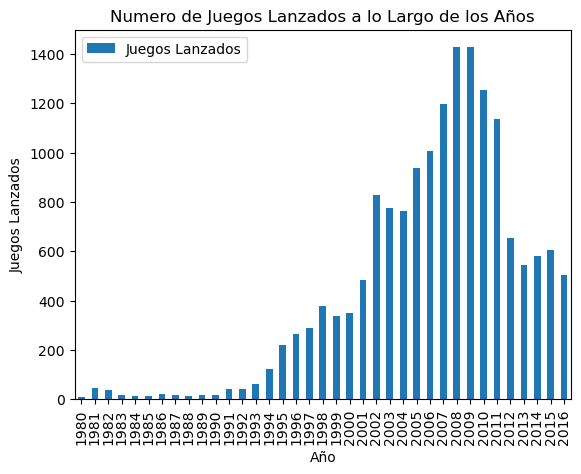

In [22]:
game_relased1 = games.groupby(['year_of_release'])['name'].count().reset_index()

game_relased1.columns = ['year_of_release', 'games_released']
game_relased1.plot(x="year_of_release", 
                   y="games_released", 
                   title="Numero de Juegos Lanzados a lo Largo de los Años", 
                   xlabel="Año", 
                   ylabel="Juegos Lanzados", 
                   kind="bar")
plt.legend(["Juegos Lanzados"])
plt.show()


Observando el comportamiento del desarrollo de los videojuegos entre 1980 y 2016, se puede afirmar que existe una clara tendencia de crecimiento. A partir de la década de 1990 se percibe un incremento significativo en la cantidad de títulos desarrollados. En 1995, por ejemplo, la cifra se disparó a alrededor de 200 videojuegos, y esta tendencia ascendente continuó hasta alcanzar su punto máximo en los años 2008 y 2009, cuando se llegaron a producir cerca de 1.400 títulos o incluso más.

Este crecimiento puede atribuirse a varios factores. Desde los años 90 comenzó a despertar un mayor interés por los videojuegos, impulsado por el avance tecnológico que permitió crear experiencias más complejas, con mejores gráficos, mayor cantidad de personajes y narrativas más elaboradas. Asimismo, la entrada de nuevas consolas, como la PlayStation en 1995, marcó un hito en la industria y contribuyó al aumento en la producción de videojuegos.

La tendencia de crecimiento se mantuvo gracias a la competencia entre empresas desarrolladoras y fabricantes de consolas, quienes buscaban posicionarse como líderes en ventas y atraer a un público cada vez más amplio. En comparación con los años 80, el salto en la producción fue altamente significativo. Sin embargo, tras alcanzar los máximos históricos, el ritmo de lanzamientos comenzó a disminuir.

Esta reducción podría explicarse por el cambio en la estrategia de la industria: ya no se trataba únicamente de ofrecer un producto, sino de crear experiencias inmersivas con historias más sólidas. Esto implicó mayores exigencias en términos de calidad, así como procesos de desarrollo más largos y complejos debido al uso de tecnologías avanzadas. En consecuencia, las empresas dedicaron más tiempo y recursos a cada título con el fin de ofrecer experiencias más gratificantes para el público.

## 5.2 Variación de las ventas de una plataforma a otra.

In [23]:
sales_platforms = games.groupby('platform')['total_sales'].sum().reset_index()
sales_platforms.columns = ['platform', 'total_sales']
sales_platforms.sample(n=10, random_state=42)

,platform,total_sales
27,WiiU,82.19
15,PS,727.58
23,SNES,200.04
17,PS3,931.34
8,GEN,28.35
9,GG,0.04
29,XB,251.57
24,TG16,0.16
12,NG,1.44
0,2600,86.48


La muestra de plataformas seleccionada refleja una distribución desigual en las ventas totales, donde consolas como PS3 y PS muestran un mayor nivel de éxito y consolidación en el mercado, mientras que otras como WiiU, SNES o XB alcanzaron resultados intermedios, en contraste con plataformas como GG, TG16 o NG, cuyas cifras fueron mucho más limitadas, lo que evidencia cómo algunas consolas lograron posicionarse con fuerza mientras la mayoría tuvo un impacto reducido.

## 5.2.1 Plataformas con las mayores ventas totales y su distribución basada en los datos de cada año.

In [24]:
top_platforms = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False).reset_index()
top_platforms.columns = ['platform', 'total_sales']
top_platforms.head()

,platform,total_sales
0,PS2,1233.56
1,X360,961.24
2,PS3,931.34
3,Wii,891.18
4,DS,802.78


<Figure size 1200x600 with 0 Axes>

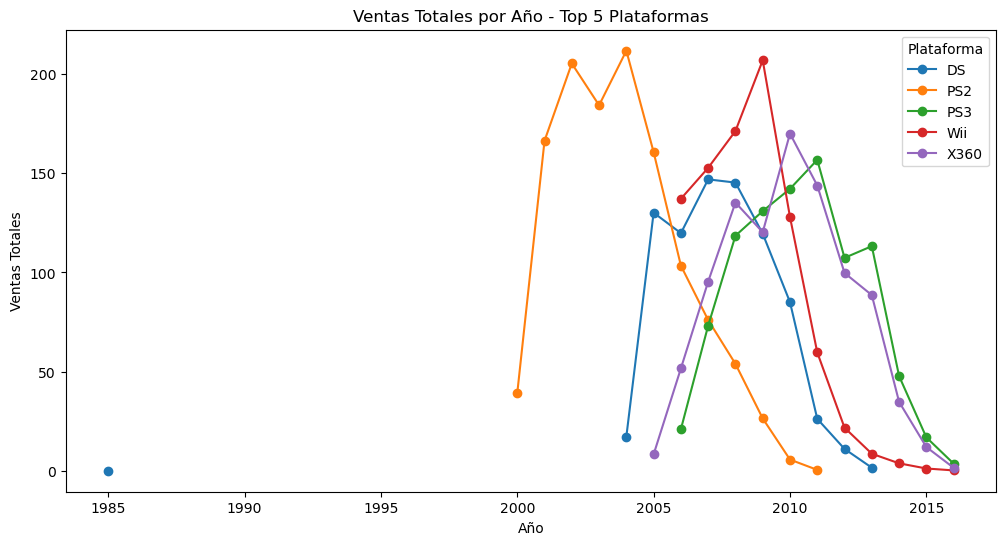

In [25]:
top5 = top_platforms.head(5)['platform'].tolist()
platform_year_sales = (games[games['platform'].isin(top5)].groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index())



platform_pivot = platform_year_sales.pivot(
    index="year_of_release", 
    columns="platform", 
    values="total_sales"
)
plt.figure(figsize=(12, 6))

platform_pivot.plot(
    kind="line", 
    marker="o", 
    title="Ventas Totales por Año - Top 5 Plataformas",
    xlabel="Año",
    ylabel="Ventas Totales",
    figsize=(12,6) )

plt.legend(title="Plataforma")
plt.show()


Se evidencia una marcada diferencia en cuanto a las ventas de videojuegos por plataforma, siendo la PlayStation 2 la que lidera ampliamente sobre las demás. Esta consola ostenta el récord de ser la más vendida en la historia, con más de 160 millones de unidades distribuidas a nivel mundial, cifra confirmada oficialmente por Sony en noviembre de 2024. Su éxito histórico se explica por diversos factores: un catálogo extenso y variado de juegos, la retrocompatibilidad con la PlayStation original, la inclusión de un reproductor de DVD y la posibilidad de jugar en línea, elementos que potenciaron su popularidad desde el momento de su lanzamiento.

En la gráfica se observa que, desde su salida al mercado, la PlayStation 2 mantuvo una tendencia de crecimiento sostenido hasta alcanzar su punto máximo alrededor del año 2004. A partir de entonces, comenzó a registrar un decrecimiento en sus ventas, posiblemente asociado a la entrada de nuevas consolas como la Nintendo DS y la Xbox 360, las cuales incorporaron innovaciones tecnológicas que captaron la atención de los usuarios y restaron protagonismo a la PS2.

En cuanto a las demás consolas, se percibe un comportamiento menos uniforme, con fluctuaciones marcadas en sus ventas. Esto puede atribuirse tanto a la intensa competencia entre fabricantes como a factores específicos de cada plataforma, tales como la disponibilidad de títulos exclusivos, la calidad de los videojuegos, la innovación tecnológica y las expectativas de los usuarios. Dichos elementos, junto con los cambios en las preferencias del mercado, explican las variaciones en los niveles de venta a lo largo del tiempo.

## 5.2.2 Plataformas que solían ser populares pero que ahora no tienen ventas. 

<Figure size 1200x600 with 0 Axes>

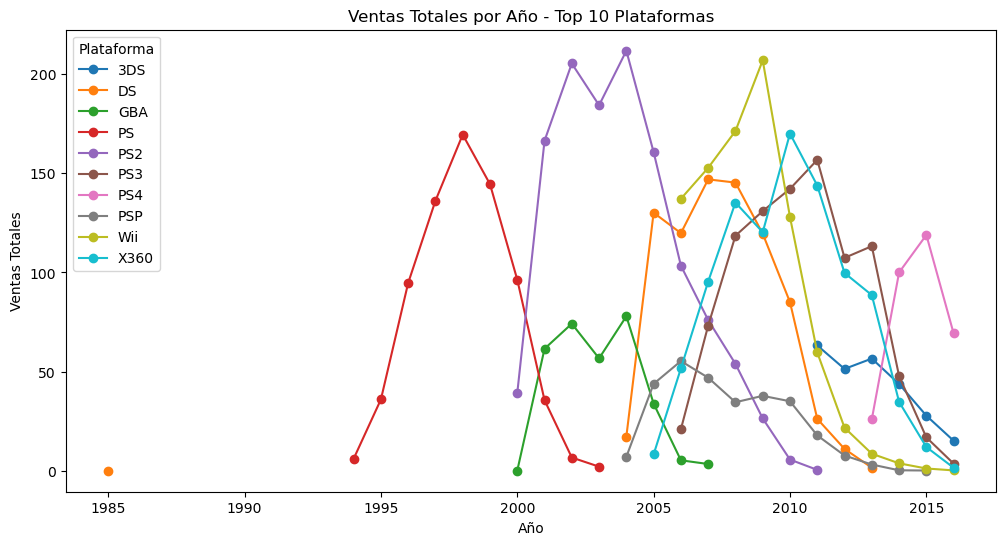

In [26]:
top10 = top_platforms.head(10)['platform'].tolist()
platform_year_sales = (games[games['platform'].isin(top10)].groupby(['year_of_release', 'platform'])['total_sales'].sum().reset_index())


platform_pivot1 = platform_year_sales.pivot(
    index="year_of_release", 
    columns="platform", 
    values="total_sales"
)
plt.figure(figsize=(12, 6))

platform_pivot1.plot(
    kind="line", 
    marker="o", 
    title="Ventas Totales por Año - Top 10 Plataformas",
    xlabel="Año",
    ylabel="Ventas Totales",
    figsize=(12,6) )

plt.legend(title="Plataforma")
plt.show()

Teniendo en cuenta la gráfica anterior, donde se observa el top 10 de ventas por consola, se puede apreciar que plataformas sumamente populares en su momento, como la PlayStation (PS), su sucesora PlayStation 2 (PS2) y la Nintendo DS, alcanzaron niveles de ventas muy elevados durante sus años de auge, aunque posteriormente dejaron de generar ingresos a medida que el mercado evolucionaba y surgieron nuevas alternativas tecnológicas.

De manera similar, consolas como la GameBoy Advance (GBA) y la PlayStation Portable (PSP) no alcanzaron cifras de ventas tan altas en comparación con las ya mencionadas. Sin embargo, ambas siguen siendo muy recordadas y valoradas por los usuarios, gracias a la innovación que aportaron y a la calidad de sus catálogos de juegos, lo que les otorgó un lugar especial dentro de la historia de los videojuegos.

## 5.2.3 ¿Cuánto tardan generalmente las nuevas plataformas en aparecer y las antiguas en desaparecer?

In [27]:
platform_lifecycle = (games.groupby('platform')['year_of_release'].agg(['min', 'max']).reset_index().rename(columns={'min': 'first_year', 'max': 'last_year'}))
platform_lifecycle['life_cycle'] = platform_lifecycle['last_year'] - platform_lifecycle['first_year'] + 1
platform_lifecycle.sample(10)

,platform,first_year,last_year,life_cycle
25,WS,1999,2001,3
16,PS2,2000,2011,12
17,PS3,2006,2016,11
19,PSP,2004,2015,12
0,2600,1980,1989,10
4,DS,1985,2013,29
27,WiiU,2012,2016,5
7,GC,2001,2007,7
13,PC,1985,2016,32
8,GEN,1990,1994,5


In [28]:
platform_lifecycle.describe()

,first_year,last_year,life_cycle
count,31.000000,31.000000,31.000000
mean,1997.645161,2005.258065,8.612903
std,9.094131,9.273503,6.998464
min,1980.000000,1989.000000,1.000000
25%,1992.500000,1996.000000,4.000000
50%,1996.000000,2007.000000,7.000000
75%,2004.500000,2016.000000,11.000000
max,2013.000000,2016.000000,32.000000


Teniendo en cuenta lo anterior, se puede afirmar que las consolas suelen tener un ciclo de vida aproximado de 8 años en el mercado. Esto puede explicarse por las constantes actualizaciones tecnológicas que incorporan las nuevas generaciones de consolas, así como por la demanda de los consumidores, que impulsa a la industria a innovar continuamente con el fin de captar la atención del público.

No obstante, existen ciertas excepciones en las que algunas consolas logran mantenerse vigentes durante periodos más prolongados. Esto puede deberse tanto a su popularidad como a la amplitud de su catálogo de servicios y videojuegos. Un ejemplo particular es el de las PC, que, si bien no son una consola en sentido estricto, ofrecen la posibilidad de ser modificadas y mejoradas en hardware y software, lo que permite que su ciclo de vida sea mucho más duradero que el de las consolas tradicionales.

## 5.3 Datos Relevantes

Teniendo en cuenta las gráficas anteriores, se decidió trabajar únicamente con los datos comprendidos desde el año 2005 en adelante, con el fin de realizar un análisis más pertinente. Esta decisión obedece a que, a partir de ese periodo, se registraron lanzamientos de consolas que aún se mantenían vigentes durante los años analizados, es decir, que continuaban generando ventas, como la Xbox 360 o la PlayStation 3 hacia el año 2016.

Esta selección resulta beneficiosa para el análisis, ya que permite concentrarse en plataformas con relevancia actual dentro del mercado y, al mismo tiempo, facilita la construcción de un modelo proyectado hacia el año 2017, tomando como referencia datos recientes y representativos de la industria.

## 5.4 ¿Qué plataformas son líderes en ventas? ¿Cuáles crecen y cuáles se reducen?

<Figure size 1200x600 with 0 Axes>

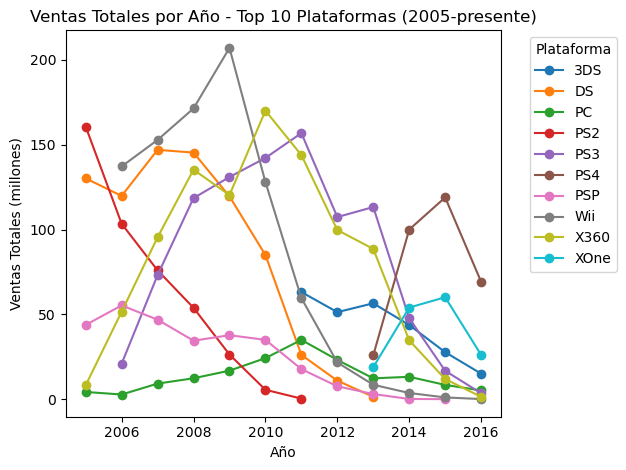

In [29]:
games_2005_onwards = games[games['year_of_release'] >= 2005]
platforms_since_2005 = (games_2005_onwards
                        .groupby('platform')['total_sales']
                        .sum()
                        .sort_values(ascending=False))
top10_since_2005 = platforms_since_2005.head(10).index.tolist()
platform_year_sales = (games_2005_onwards[games_2005_onwards['platform'].isin(top10_since_2005)]
                       .groupby(['year_of_release', 'platform'])['total_sales']
                       .sum().reset_index())
platform_pivot1 = platform_year_sales.pivot(
    index="year_of_release", 
    columns="platform", 
    values="total_sales"
)

plt.figure(figsize=(12, 6))
platform_pivot1.plot(
    kind="line", 
    marker="o", 
    title="Ventas Totales por Año - Top 10 Plataformas (2005-presente)",
    xlabel="Año",
    ylabel="Ventas Totales (millones)"
)
plt.legend(title="Plataforma", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

De la gráfica anterior se pueden identificar varias particularidades en cuanto a las ventas de consolas. A primera vista, se observa que la Wii aparece como la plataforma líder, alcanzando un máximo de alrededor de 200 millones de dólares en ventas totales. Sin embargo, este dato puede resultar engañoso, ya que tras llegar a su punto más alto en 2009, la consola experimentó un declive constante en sus ventas, lo que indica que su liderazgo fue sostenido únicamente durante un corto periodo.

Al analizar con mayor detalle, se aprecia que las plataformas con mayor estabilidad y presencia prolongada en el mercado fueron la PlayStation 3 (PS3) y la Xbox 360 (X360). Ambas mostraron un crecimiento sostenido desde su lanzamiento y lograron mantener un volumen significativo de ventas a lo largo de varios años. No obstante, como se mencionó anteriormente, la duración promedio de las consolas en el mercado ronda los 8 años, y efectivamente, después de alcanzar su punto máximo hacia 2011, tanto PS3 como X360 empezaron a disminuir en ventas. Este descenso también coincidió con la entrada de nuevas generaciones, como la Nintendo 3DS en 2011 y la PlayStation 4 (PS4) en 2013.

En este sentido, la PS4 mostró un lanzamiento sólido y un comportamiento positivo en ventas, aunque no tan elevado como su predecesora, la PS3. Aun así, tiene el potencial para consolidarse como líder frente a su competencia directa en ese periodo. En contraste, la Xbox One (XONE), también lanzada en 2013 a persar de estar en el top, no genero mayores ventas que PS4. Esto se atribuye a varias controversias que acompañaron su lanzamiento: su precio elevado de 499 dólares, la obligatoriedad inicial del sensor Kinect, la exigencia de conexión a internet cada 24 horas y un sistema de licencias digitales que limitaba la compraventa de juegos usados. Estas decisiones generaron un fuerte rechazo en la comunidad gamer y afectaron negativamente sus ventas frente a la PS4.

Teniendo en cuenta este panorama, las consolas con mayor proyección de rentabilidad serían principalmente la PS4, por su buena acogida y ventas significativas desde su lanzamiento, y en menor medida la Xbox One, que, pese a sus controversias iniciales, sigue siendo la competidora directa de Sony, lo que abre la posibilidad de estrategias enfocadas en títulos exclusivos o experiencias diferenciadas. Finalmente, también resulta relevante considerar a las PC. Su durabilidad como plataforma, la posibilidad de mejorar su hardware, la gran diversidad de juegos disponibles y la integración con servicios de Microsoft (que incluye beneficios vinculados a Xbox) la convierten en una alternativa atractiva y sostenible para la comunidad gamer.

## 5.5 Diagrama de caja para las ventas globales de todos los juegos

<Figure size 1500x800 with 0 Axes>

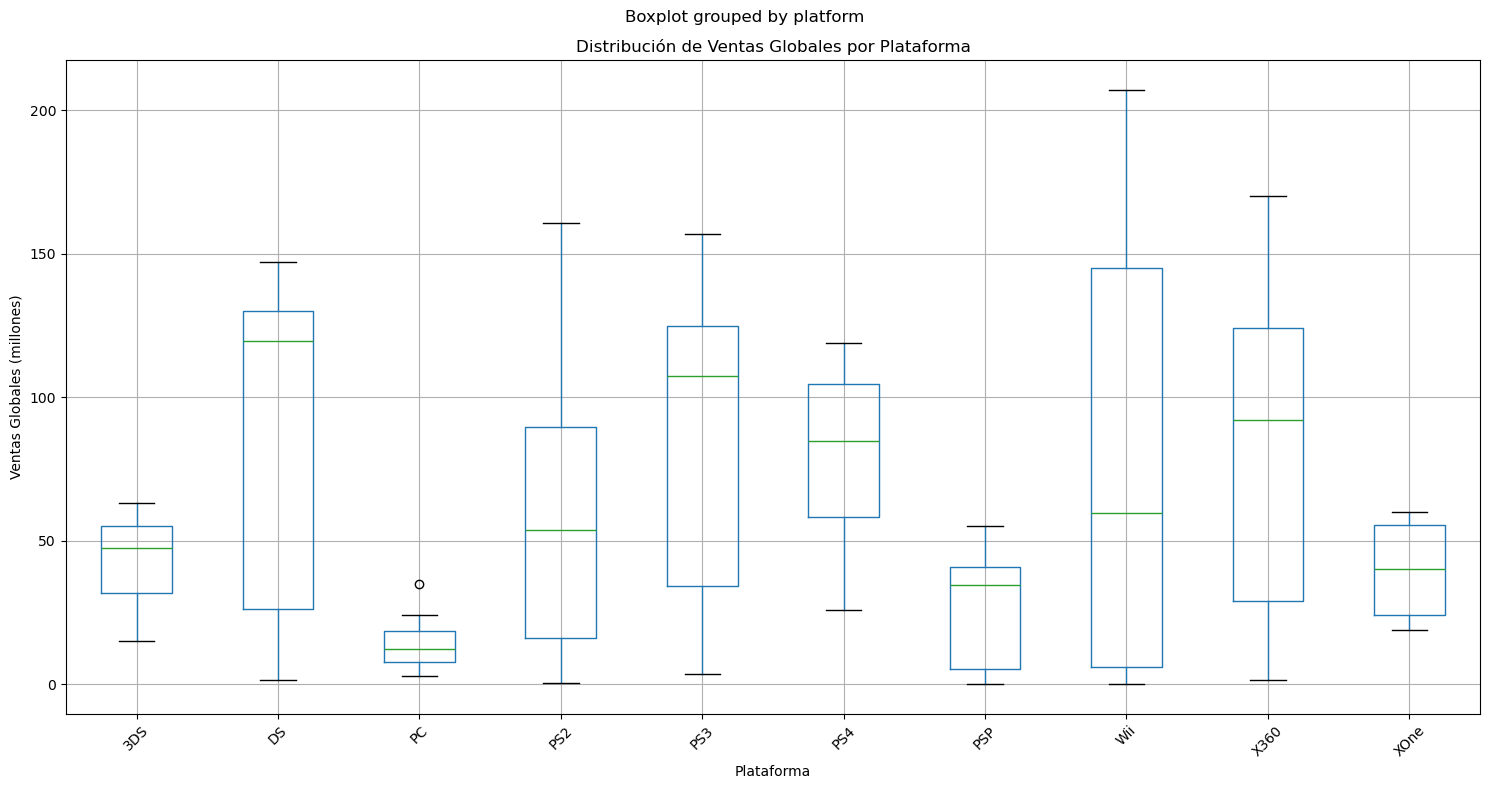

In [30]:
games_2005_onwards = games[games['year_of_release'] >= 2005]
platforms_since_2005 = (games_2005_onwards
                        .groupby('platform')['total_sales']
                        .sum()
                        .sort_values(ascending=False))
top10_since_2005 = platforms_since_2005.head(10).index.tolist()
platform_year_sales = (games_2005_onwards[games_2005_onwards['platform'].isin(top10_since_2005)]
                       .groupby(['year_of_release', 'platform'])['total_sales']
                       .sum().reset_index())

plt.figure(figsize=(15, 8))
platform_year_sales.boxplot(column='total_sales', by='platform', figsize=(15, 8))
plt.title('Distribución de Ventas Globales por Plataforma')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Globales (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
estadisticas_plataforma = platform_year_sales.groupby('platform')['total_sales'].describe()
print(estadisticas_plataforma)

          count       mean        std    min      25%      50%       75%  \
platform                                                                   
3DS         6.0  42.968333  18.278261  15.14  31.7750   47.560   55.2675   
DS          9.0  87.276667  58.916745   1.54  26.1800  119.540  130.1400   
PC         12.0  13.982500   9.501110   2.85   7.7025   12.400   18.4875   
PS2         7.0  60.922857  57.640889   0.45  16.0200   53.900   89.7050   
PS3        11.0  84.667273  54.637565   3.60  34.3600  107.360  124.7250   
PS4         4.0  78.535000  40.567917  25.99  58.4350   84.625  104.7250   
PSP        11.0  25.679091  20.412135   0.12   5.4150   34.550   40.8100   
Wii        11.0  81.016364  79.136330   0.18   6.1700   59.650  144.9600   
X360       12.0  80.103333  57.484408   1.52  29.0450   91.995  124.0325   
XOne        4.0  39.830000  20.313977  18.96  24.3525   40.110   55.5875   

             max  
platform          
3DS        63.20  
DS        146.94  
PC         

En base a la gráfica anterior, se observa que las ventas de las consolas varían de manera significativa, lo cual está relacionado tanto con el tipo de consola como con el grado de innovación tecnológica que cada una ofreció en su momento. Un ejemplo claro de ello son las consolas portátiles: la Nintendo DS lideró las ventas gracias a su modelo innovador de doble pantalla y funciones táctiles. No obstante, su sucesora, la Nintendo 3DS, aunque logró generar ventas considerables, no alcanzó el mismo nivel de éxito que la DS.

Por otra parte, tal como se mencionó anteriormente, la competencia entre la PlayStation 3 (PS3) y la Xbox 360 fue muy reñida. Sin embargo, al analizar los promedios de ventas, la PS3 mostró una ligera ventaja, con 84,67 millones frente a los 80,10 millones de la Xbox 360.

Asimismo, se reafirma que el lanzamiento de la PlayStation 4 (PS4) fue un verdadero éxito. En términos de ventas promedio, la PS4 prácticamente duplicó a su competidora directa, la Xbox One (XONE), alcanzando 78,53 millones, mientras que la XONE solo llegó a 39,83 millones. Este contraste evidencia la diferencia en la aceptación del mercado y consolida a la PS4 como una de las plataformas más relevantes de su generación.

Finalmente, se observa que la PS4, a pesar de llevar menos tiempo en el mercado, ya presenta un promedio de ventas cercano al de la PS3 en toda su vida útil. Este comportamiento puede explicarse tanto por una acogida similar en términos de demanda como también por factores económicos, como la inflación de precios en el sector. Dicho efecto hace que la PS4, al ser más reciente, esté condicionada por valores de venta más elevados, lo que contribuye a que alcance rápidamente promedios similares a los de su predecesora.

## 5.6 Cómo las reseñas de usuarios y profesionales afectan las ventas de una plataforma popular.

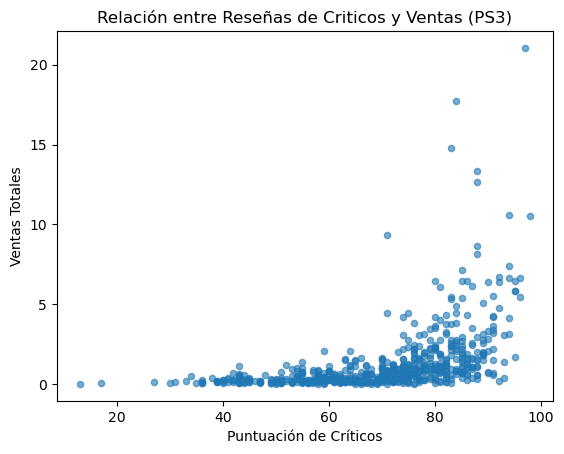

In [32]:
ps3_games = games[games['platform'] == 'PS3']
ps3_reviews = (ps3_games.groupby(['critic_score', 'user_score'])['total_sales'].sum().sort_values(ascending=False)).reset_index()
ps3_reviews.columns = ["critic_score", "user_score", 'total_sales']
ps3_reviews.plot(x='critic_score', y='total_sales', kind='scatter', alpha=0.6)
plt.xlabel('Puntuación de Críticos')
plt.ylabel('Ventas Totales')
plt.title('Relación entre Reseñas de Criticos y Ventas (PS3)')
plt.show()

In [33]:
correalacion = ps3_reviews['critic_score'].corr(ps3_reviews['total_sales'])
print(f"La correlación entre la crtica de los usarios y las ventas totales de la PS3 es {correalacion}")

La correlación entre la crtica de los usarios y las ventas totales de la PS3 es 0.4768943594277745


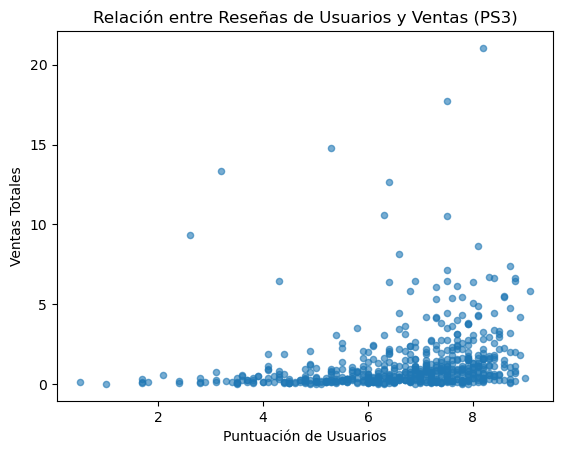

In [34]:
ps3_games = games[games['platform'] == 'PS3']
ps3_reviews = (ps3_games.groupby(['critic_score', 'user_score'])['total_sales'].sum().sort_values(ascending=False)).reset_index()
ps3_reviews.columns = ["critic_score", "user_score", 'total_sales']
ps3_reviews.plot(x='user_score', y='total_sales', kind='scatter', alpha=0.6)
plt.xlabel('Puntuación de Usuarios')
plt.ylabel('Ventas Totales')
plt.title('Relación entre Reseñas de Usuarios y Ventas (PS3)')
plt.show()

In [35]:

correalacion1 = ps3_reviews['user_score'].corr(ps3_reviews['total_sales'])
print(f"La correlación entre la crtica de los usarios y las ventas totales de la PS3 es {correalacion1}")


La correlación entre la crtica de los usarios y las ventas totales de la PS3 es 0.20324027434172973


In [36]:
correlation_matrix = ps3_reviews[['critic_score', 'user_score', 'total_sales']].corr()
print(correlation_matrix)

              critic_score  user_score  total_sales
critic_score      1.000000    0.619551     0.476894
user_score        0.619551    1.000000     0.203240
total_sales       0.476894    0.203240     1.000000


Al observar la correlación entre las reseñas de la crítica especializada y las reseñas de los usuarios, se puede afirmar que estas no generan un impacto significativo en las ventas de los videojuegos para la PS3.

Por un lado, los comentarios de la crítica muestran una correlación cercana a 0,4, lo cual indica un efecto moderado, pero no lo suficientemente determinante como para influir de manera directa en las ventas. Por otro lado, las reseñas de los usuarios presentan una correlación aún más baja, cercana a 0,2, lo que evidencia que su influencia es prácticamente nula, dado que el valor tiende hacia 0, es decir, ausencia de relación.

Ahora bien, si ambas variables se analizan de manera conjunta es decir, considerando tanto las críticas de los usuarios como las de la prensa especializada, se alcanza un valor aproximado de 0,6. Aunque este nivel de correlación sigue sin ser altamente significativo, sí resulta un indicador que conviene tener en cuenta, pues puede reflejar que, en ciertos casos, la combinación de ambos tipos de reseñas podría ejercer un leve efecto positivo o negativo sobre las ventas totales de los juegos en esta consola.

## 5.7 Comparativa de las ventas de los mismos juegos en otras plataformas.

In [37]:
same_game = games[games['name'] == 'Far Cry 3']
print(same_game[['name', 'platform', 'total_sales', 'critic_score', 'user_score']])

           name platform  total_sales  critic_score  user_score
401   Far Cry 3      PS3         3.35          90.0         8.5
471   Far Cry 3     X360         3.00          91.0         8.6
2136  Far Cry 3       PC         0.96          88.0         8.2


Como se puede observar, en la plataforma PS3 se registraron mayores ventas del videojuego Far Cry 3 en comparación con Xbox 360 y PC. Este hecho refuerza lo señalado anteriormente: a pesar de que las calificaciones otorgadas por la crítica y los usuarios en PS3 fueron ligeramente inferiores a las de Xbox 360 (con aproximadamente un punto de diferencia en ambos casos), esto no representó un efecto negativo en las ventas. En concreto, las ventas en PS3 alcanzaron los 3,35 millones de copias, frente a los 3,00 millones en Xbox 360, aun cuando esta última obtuvo mejores valoraciones.

En el caso de PC, aunque las calificaciones fueron más bajas, las ventas también resultaron menores. Esto coincide con lo ya mencionado: los PC no siempre tienen una representación significativa en las ventas de ciertos videojuegos, especialmente cuando se trata de títulos diseñados y optimizados para consolas.

Por lo tanto, se puede concluir que la calificación, tanto de usuarios como de la crítica, no siempre es un factor determinante en el volumen de ventas de un videojuego, como se evidencia en este caso. No obstante, es importante considerar la existencia de casos atípicos, en los que las reseñas pueden tener un impacto más marcado, aunque estos suelen ser escenarios excepcionales.

## 5.8 Distribución general de los juegos por género.

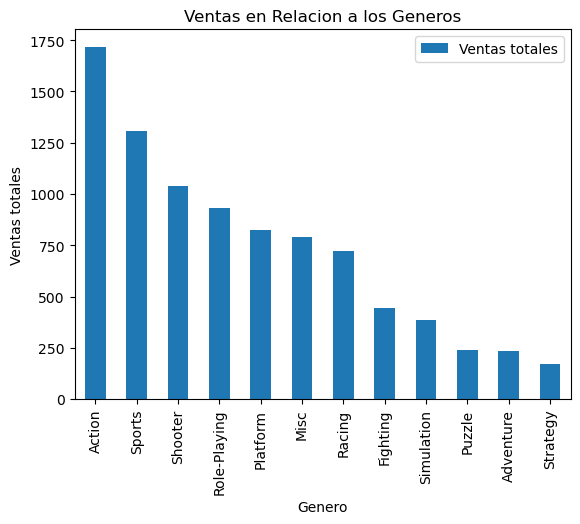

In [38]:
sales_genre = games.groupby('genre')['total_sales'].sum().sort_values(ascending=False).reset_index()
sales_genre.columns = ['genre', 'total_sales']
sales_genre.plot(x="genre", 
                   y="total_sales", 
                   title="Ventas en Relacion a los Generos", 
                   xlabel="Genero", 
                   ylabel="Ventas totales", 
                   kind="bar")
plt.legend(["Ventas totales"])
plt.show()

Observando la grafica anterior, se puede afirmar que los generos mas rentables eria el de accion, se puede deber a la gran varierdad de juegos que existen en relacion a este genero y a las emociones que pueden trasmintir en el publico, a lo que le sigue el genero de deportes, sin embargo para este genero tambien hay que tener en cuenta un factor en relacion a los datos, dado que como habiamos observado anteriormente, la consola de nintendo Wii llego a un punto de ventas donde supero a muchas otras, esto puede incluso asoriciarse a su mayor exito en la consola que fue Wii Sports, lo que hizo que fuera su juego mas rentable, se puede asociar ese factor con que este genero este de segundo, claro esta, tambien se puede atribuir a otros juegos de deportes, pero hay que tener en cuenta ese factor al analizarlo y como tercer los lugar estan los Shooter, tambien esta un poco relacionado con los de accion, lo que hace que sea rentable tambien este genero. En cuanto a las ventas, se podria decir que los generos estan relacionados a lo que busca cada consumidor, como se meciono al inicio los de accion peuden estar de primeros por las emociones de adrenalina y dopamina que pueden generar en los usuarios, siendo por eso los princiaples a diferencia del que menos ventas tiene que son los de estrategia, por lo que requiere mas pociencia y planificacion para llevar a cabo movimientos acertados para lograr el exito, y los podemos ver tambien con los otros dos ultimos como los de aventura y puzzle, que requieren mayor concentracion a diferencia del top 3 que son de presentan al publico mas emciones y los que se encuentran en el medio seria una mezcla de emociones y movimiento lo que hace que tengan ventas, pero no tan representativas como no tan bajas. 

## 6. PERFIL DE USUARIO PARA CADA REGIÓN

## 6.1 Las cinco plataformas principales.

## LAS CINCO PLATAFORMAS PRINCIPALES DE NORTEAMERICA 

<Figure size 1200x600 with 0 Axes>

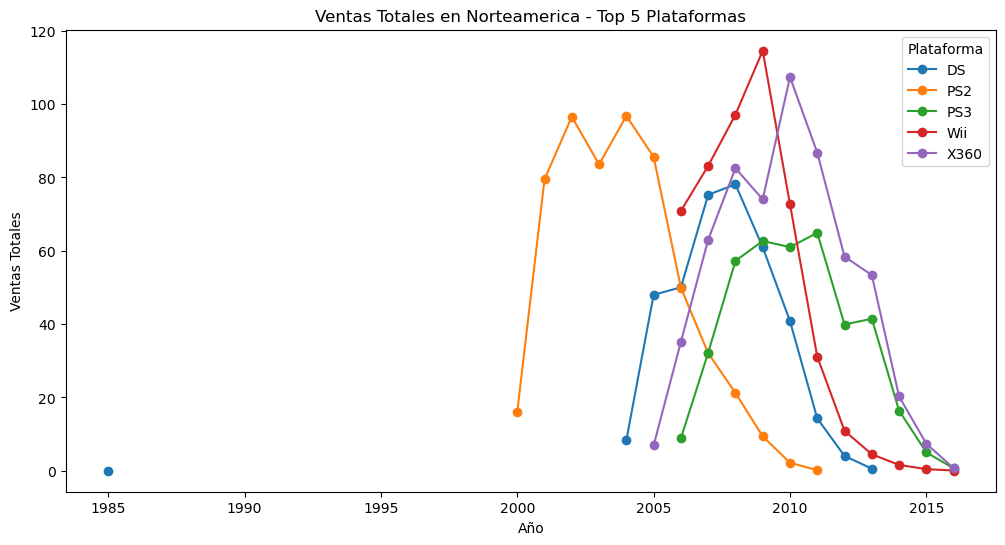

In [39]:
top5_na = games.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5).index.tolist()
platform_year_sales = (games[games['platform'].isin(top5_na)].groupby(['year_of_release', 'platform'])['na_sales'].sum().reset_index())
platform_pivot = platform_year_sales.pivot(
    index="year_of_release", 
    columns="platform", 
    values="na_sales"
)
plt.figure(figsize=(12, 6))

platform_pivot.plot(
    kind="line", 
    marker="o", 
    title="Ventas Totales en Norteamerica - Top 5 Plataformas",
    xlabel="Año",
    ylabel="Ventas Totales",
    figsize=(12,6) )

plt.legend(title="Plataforma")
plt.show()

## LAS CINCO PLATAFORMAS PRINCIPALES DE EUROPA 

<Figure size 1200x600 with 0 Axes>

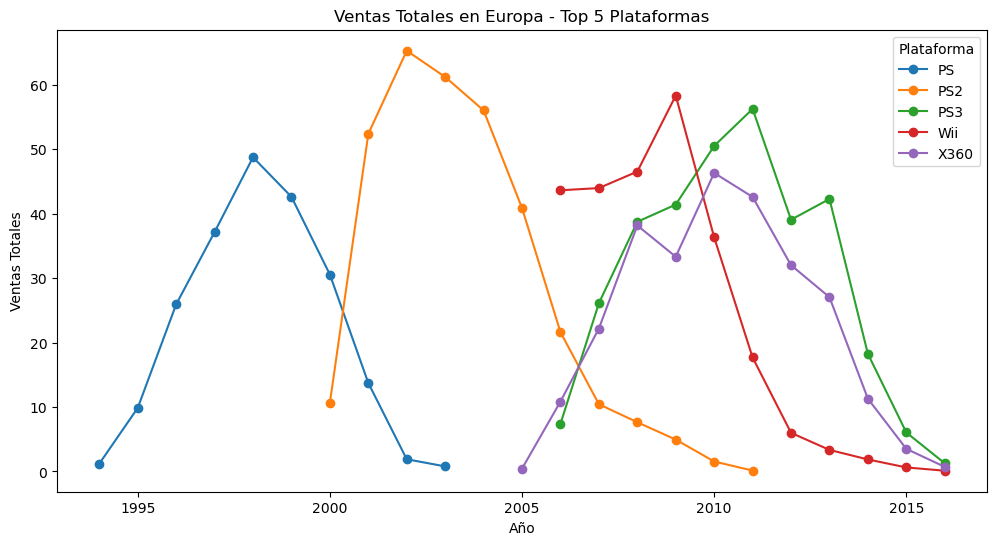

In [40]:
top5_eu = games.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5).index.tolist()
platform_year_sales = (games[games['platform'].isin(top5_eu)].groupby(['year_of_release', 'platform'])['eu_sales'].sum().reset_index())
platform_pivot = platform_year_sales.pivot(
    index="year_of_release", 
    columns="platform", 
    values="eu_sales"
)
plt.figure(figsize=(12, 6))

platform_pivot.plot(
    kind="line", 
    marker="o", 
    title="Ventas Totales en Europa - Top 5 Plataformas",
    xlabel="Año",
    ylabel="Ventas Totales",
    figsize=(12,6) )

plt.legend(title="Plataforma")
plt.show()

## LAS CINCO PLATAFORMAS PRINCIPALES DE JAPON 

<Figure size 1200x600 with 0 Axes>

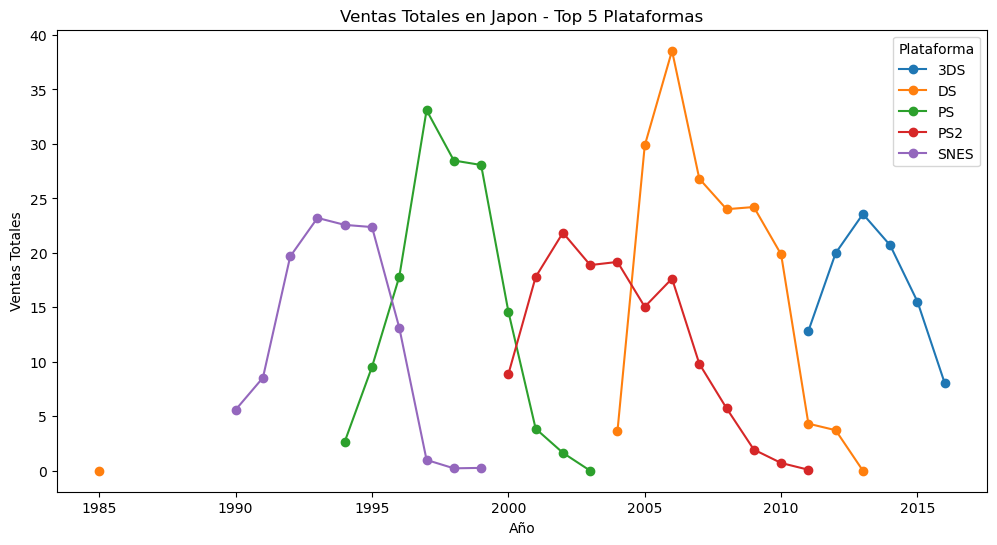

In [41]:
top5_jp = games.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5).index.tolist()
platform_year_sales = (games[games['platform'].isin(top5_jp)].groupby(['year_of_release', 'platform'])['jp_sales'].sum().reset_index())
platform_pivot = platform_year_sales.pivot(
    index="year_of_release", 
    columns="platform", 
    values="jp_sales"
)
plt.figure(figsize=(12, 6))

platform_pivot.plot(
    kind="line", 
    marker="o", 
    title="Ventas Totales en Japon - Top 5 Plataformas",
    xlabel="Año",
    ylabel="Ventas Totales",
    figsize=(12,6) )

plt.legend(title="Plataforma")
plt.show()

A partir de las gráficas que muestran el comportamiento de las principales consolas en los mercados más representativos Estados Unidos, Europa y Japón, es posible identificar diferencias relevantes en cada región.

En primer lugar, aunque la PlayStation 2 (PS2) es un producto japonés, su mayor acogida no se dio en Japón, sino en Europa y Norteamérica, siendo este último el mercado donde alcanzó el mayor volumen de ventas. Por el contrario, en Japón su impacto fue mucho más limitado.

En el caso de Estados Unidos, se evidencia un fuerte vínculo con la Xbox 360, considerada como la consola nacional. Esta tuvo una participación muy significativa en las ventas, superando a la PS3, que si bien registró presencia, no logró alcanzar un peso equiparable. Esto refleja una preferencia marcada por la producción local y por un catálogo de títulos mejor adaptado al público estadounidense.

Por otra parte, es importante resaltar que las tres regiones analizadas muestran comportamientos muy distintos. En Norteamérica, debido a su extensión territorial y mayor población, se observa una tendencia a la diversificación: en un mismo periodo de tiempo coexisten varias consolas representativas (DS, PS2, PS3, Xbox 360 y Nintendo Wii). Este fenómeno puede explicarse tanto por la amplia oferta como por la posibilidad de que un mismo hogar adquiera más de una consola.

En contraste, en Japón predomina una mayor lealtad y durabilidad en el uso de las consolas. Esto podría asociarse a factores culturales relacionados con el cuidado y la preservación de los objetos, lo que permite prolongar su vida útil. Un ejemplo claro es la Nintendo NES, que continuó generando ventas incluso después de casi diez años de su lanzamiento, manteniéndose como una de las consolas más longevas en el mercado japonés. Además, la preferencia por la marca Nintendo es evidente, especialmente con la Nintendo DS, cuya accesibilidad, portabilidad y facilidad de uso la convirtieron en la más vendida en la región.

En cuanto a Europa, se observa una clara inclinación hacia la marca PlayStation, ya que sus tres generaciones (PS2, PS3 y PS4) aparecen dentro del top de ventas. Esto demuestra una fidelidad constante hacia Sony y una ventaja sostenida frente a la Xbox 360 e incluso sobre la Nintendo Wii, que si bien tuvo un fuerte impacto global, no logró superar a la línea PlayStation en este mercado.

En síntesis, el análisis comparativo evidencia que:

En Estados Unidos, predomina la preferencia por Xbox y la diversidad de consolas.

En Japón, se valora la durabilidad y la portabilidad, con Nintendo como marca líder.

En Europa, PlayStation mantiene un dominio sólido a lo largo de varias generaciones.


## 6.2 Los cinco géneros principales. 

## LOS CINCO GENEROS PRINCIPALES DE NORTEAMERICA 

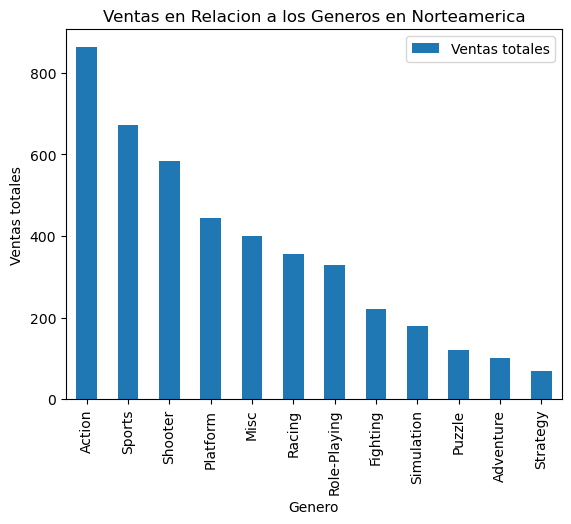

In [42]:
sales_genre_na = games.groupby('genre')['na_sales'].sum().sort_values(ascending=False).reset_index()
sales_genre_na.columns = ['genre', 'na_sales']
sales_genre_na.plot(x="genre", 
                   y="na_sales", 
                   title="Ventas en Relacion a los Generos en Norteamerica", 
                   xlabel="Genero", 
                   ylabel="Ventas totales", 
                   kind="bar")
plt.legend(["Ventas totales"])
plt.show()

## LOS CINCO GENEROS PRINCIPALES DE JAPON 

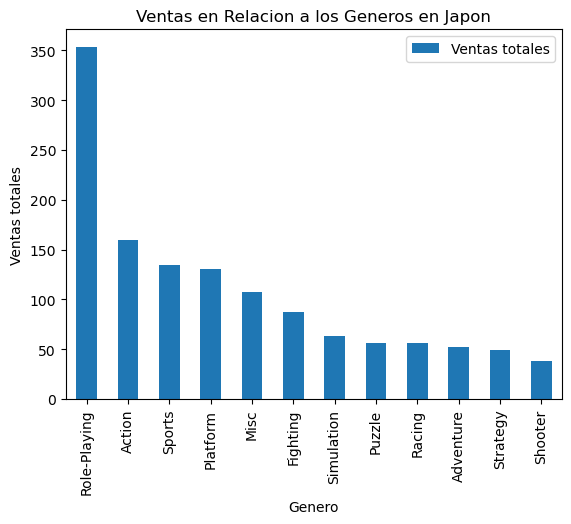

In [43]:
sales_genre_jp = games.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).reset_index()
sales_genre_jp.columns = ['genre', 'jp_sales']
sales_genre_jp.plot(x="genre", 
                   y="jp_sales", 
                   title="Ventas en Relacion a los Generos en Japon", 
                   xlabel="Genero", 
                   ylabel="Ventas totales", 
                   kind="bar")
plt.legend(["Ventas totales"])
plt.show()

## LOS CINCO GENEROS PRINCIPALES DE EUROPA 

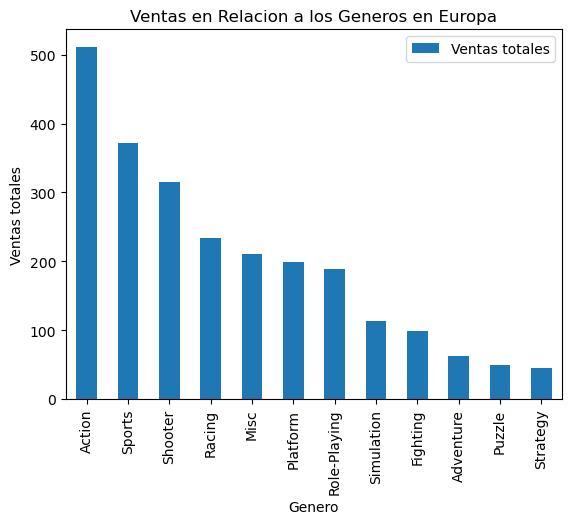

In [44]:
sales_genre_eu = games.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).reset_index()
sales_genre_eu.columns = ['genre', 'eu_sales']
sales_genre_eu.plot(x="genre", 
                   y="eu_sales", 
                   title="Ventas en Relacion a los Generos en Europa", 
                   xlabel="Genero", 
                   ylabel="Ventas totales", 
                   kind="bar")
plt.legend(["Ventas totales"])
plt.show()

Teniendo en cuenta las gráficas anteriores, se puede afirmar que el comportamiento en cuanto a las preferencias de géneros en los mercados norteamericano y europeo es bastante similar. En ambos casos, el género de acción ocupa el primer lugar, seguido por los deportes en segunda posición y los shooter en tercer lugar. La principal diferencia entre estas dos regiones no radica en el orden de preferencias, sino en el volumen de ventas, ya que en Estados Unidos, debido a las características de su mercado y a la amplitud de su población, se registran cifras mucho más altas que en Europa.

Por otro lado, el caso de Japón presenta un comportamiento completamente diferente. Allí, el género más consumido es el de rol (RPG), lo que se encuentra estrechamente relacionado con la cultura japonesa, que tiende a valorar experiencias narrativas profundas, la exploración de la identidad y el desarrollo de habilidades como la estrategia y el trabajo en equipo. Esto explica por qué los RPG se posicionan como los favoritos en esta región.

En cuanto a los demás géneros en Japón, los de acción y deportes también ocupan posiciones destacadas, pero con un peso mucho menor que los RPG. Un dato particular es que, a diferencia de Estados Unidos y Europa, los shooter se ubican en el último lugar dentro de las preferencias japonesas. Esto refuerza la idea de que el público japonés busca experiencias más inmersivas, narrativas y estratégicas, en lugar de dinámicas más repetitivas o centradas únicamente en la acción directa.

## 6.3 Si las clasificaciones de ESRB afectan a las ventas en regiones individuales.

## EFECTO DE LAS CLASIFICACIONES EN LAS VENTAS DE NORTEAMERICA

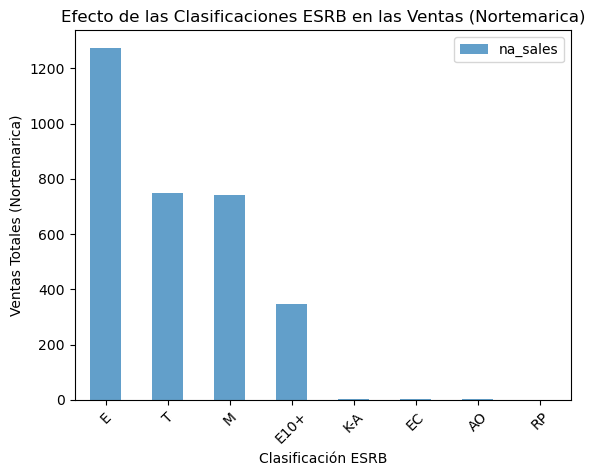

In [45]:
na_rating = games.groupby('rating')['na_sales'].sum().sort_values(ascending=False).reset_index()
na_rating.columns = ["rating", 'na_sales']
na_rating.plot(x='rating', y='na_sales', kind='bar', alpha=0.7)
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas Totales (Nortemarica)')
plt.title('Efecto de las Clasificaciones ESRB en las Ventas (Nortemarica)')
plt.xticks(rotation=45)
plt.show()

## EFECTO DE LAS CLASIFICACIONES EN LAS VENTAS DE EUROPA

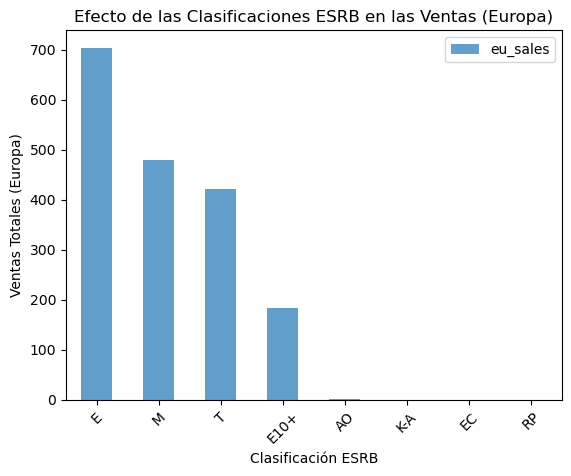

In [46]:
eu_rating = games.groupby('rating')['eu_sales'].sum().sort_values(ascending=False).reset_index()
eu_rating.columns = ["rating", 'eu_sales']
eu_rating.plot(x='rating', y='eu_sales', kind='bar', alpha=0.7)
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas Totales (Europa)')
plt.title('Efecto de las Clasificaciones ESRB en las Ventas (Europa)')
plt.xticks(rotation=45)
plt.show()

## EFECTO DE LAS CLASIFICACIONES EN LAS VENTAS DE JAPON

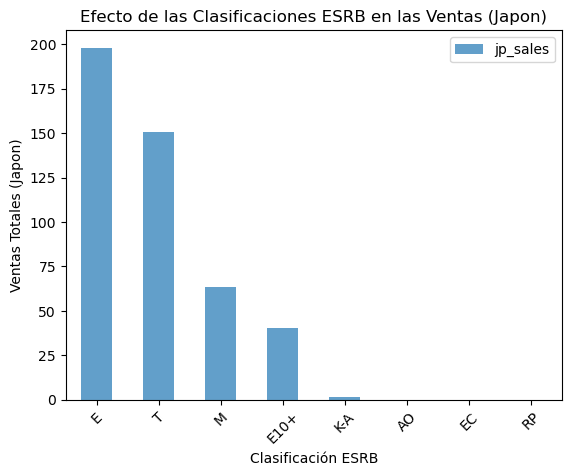

In [47]:
jp_rating = games.groupby('rating')['jp_sales'].sum().sort_values(ascending=False).reset_index()
jp_rating.columns = ["rating", 'jp_sales']
jp_rating.plot(x='rating', y='jp_sales', kind='bar', alpha=0.7)
plt.xlabel('Clasificación ESRB')
plt.ylabel('Ventas Totales (Japon)')
plt.title('Efecto de las Clasificaciones ESRB en las Ventas (Japon)')
plt.xticks(rotation=45)
plt.show()

Teniendo en cuenta las clasificaciones de la ESRB, se puede afirmar que estas sí tienen un impacto en las ventas de los videojuegos. Esto se debe a que no todos los títulos son aptos para todo público: algunos requieren clasificación M (Mature, para adultos) o T (Teen, para adolescentes), lo cual restringe su alcance en ciertos segmentos de mercado.

Las gráficas anteriores muestran que los juegos con clasificación E (Everyone, para todos) tienden a registrar mayores ventas en los tres mercados analizados, precisamente porque abarcan un público más amplio, incluidos niños y familias.

En Norteamérica, este efecto es más evidente, dado que gran parte del mercado está compuesto por jóvenes, y además los padres ejercen un mayor control sobre los contenidos que consumen sus hijos, lo que impulsa las ventas de títulos con clasificaciones más abiertas.

En el caso de Europa, las ventas presentan una tendencia más equilibrada hacia títulos orientados a un público mayor. Esto refleja una preferencia cultural por videojuegos con contenidos más profundos y específicos, en lugar de priorizar únicamente la accesibilidad para todas las edades.

Finalmente, en Japón se observa un comportamiento similar al de Norteamérica: existe una inclinación hacia títulos con clasificaciones aptas para un público más amplio, lo cual se relaciona con un contexto familiar y social que favorece la elección de videojuegos que puedan ser disfrutados por diferentes grupos de edad.

## 7. PRUEBA DE LAS SIGUIENTES HIPÓTESIS

## Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.

In [48]:
#Hipotesis nula es que Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.
#Hipotesis alternativa es que Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC no son las mismas.
datos_xbox = games[games['platform'] == 'XOne']['user_score'].dropna()
datos_pc = games[games['platform'] == 'PC']['user_score'].dropna()

alpha = 0.05

results = st.ttest_ind(datos_xbox, datos_pc)

print('valor p: ', results.pvalue)

if results.pvalue < alpha: 
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  1.3037979620149106e-05
Rechazamos la hipótesis nula


Para poder analizar los resultados, es necesario explicar primero cómo se formularon la hipótesis nula (H₀) y la hipótesis alternativa (H₁).

En estadística, la hipótesis nula suele expresar la idea de que no existen diferencias significativas entre los grupos. En este caso:

H₀: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son iguales.

H₁: Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.

La hipótesis nula asume que no existe ningún cambio o efecto relevante entre los grupos. Sin embargo, al realizar la prueba de hipótesis, los resultados muestran que las calificaciones promedio otorgadas por los usuarios a las plataformas mencionadas difieren de manera significativa, dado que el valor p obtenido es menor al nivel de significancia establecido (α = 0,05). Esto nos lleva a rechazar H₀ y aceptar H₁.

En consecuencia, se puede concluir que sí existe una diferencia estadísticamente significativa en las calificaciones promedio de los usuarios entre Xbox One y PC.

## Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

In [49]:
#Hipotesis nula es que Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.
#Hipotesis alternativa es que Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.
datos_accion = games[games['genre'] == 'Action']['user_score'].dropna()
datos_deportes = games[games['genre'] == 'Sports']['user_score'].dropna()

alpha = 0.05

results = st.ttest_ind(datos_accion, datos_deportes)

print('valor p: ', results.pvalue)

if results.pvalue < alpha: 
    print("Rechazamos la hipótesis nula")
else:
    print("No podemos rechazar la hipótesis nula")

valor p:  0.06480928064420527
No podemos rechazar la hipótesis nula


Para analizar los resultados, es necesario explicar primero cómo se formularon la hipótesis nula (H₀) y la hipótesis alternativa (H₁).

En estadística, la hipótesis nula suele expresar la idea de que no existen diferencias significativas entre los grupos. En este caso:

H₀: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.

H₁: Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.

La hipótesis nula asume que no existe ningún cambio o efecto relevante entre ambos géneros. Al realizar la prueba de hipótesis, se obtuvo un valor p = 0.0648, el cual es mayor que el nivel de significancia establecido (α = 0,05). Esto significa que no se cuenta con evidencia suficiente para rechazar H₀, por lo que se acepta la hipótesis nula.

En consecuencia, se concluye que no existe una diferencia estadísticamente significativa en las calificaciones promedio otorgadas por los usuarios a los géneros de Acción y Deportes. No obstante, este resultado invita a reflexionar sobre por qué dos géneros aparentemente distintos reciben valoraciones similares por parte de los jugadores.

## 8. CONCLUSIÓN GENERAL

Una vez realizado el análisis completo de la información proporcionada, se puede afirmar que resulta de vital importancia comprender el comportamiento de los consumidores en las distintas regiones. Al observar el panorama general, notamos que las ventas globales representan solo una pequeña fracción de lo que, de manera individual, puede explicarnos cada mercado.

Por ejemplo, en el caso de Japón, se evidencian preferencias muy distintas a las de los mercados norteamericano y europeo, lo cual responde en gran medida a factores culturales. Mientras que en Japón los consumidores tienden a conservar una consola durante todo su ciclo de vida antes de reemplazarla, en Estados Unidos y en gran parte de Europa los jugadores suelen adquirir varias consolas de manera simultánea o reemplazarlas con mayor frecuencia. Asimismo, la extensión geográfica y la densidad poblacional explican en parte por qué el mercado norteamericano concentra un mayor volumen de ventas.

Estos aspectos resultan fundamentales al momento de diseñar una estrategia de mercado, ya que es necesario conocer con claridad hacia dónde se quiere dirigir la oferta. En este sentido, también es clave identificar las consolas en crecimiento para aprovechar su potencial, como es el caso de la PS4 y la Xbox One, que al momento del análisis solo llevaban tres años desde su lanzamiento y no habían alcanzado aún el promedio de vida útil en el mercado. Esto representa una oportunidad para introducir títulos atractivos para el público.

En cuanto a las clasificaciones, conviene priorizar videojuegos aptos para todo público en los tres mercados, dado que garantizan un alcance más amplio. No obstante, se deben considerar las particularidades culturales de cada región:

En Europa, la estrategia debería incluir títulos con tramas más profundas y maduras, alineados con sus preferencias.

En Japón, es recomendable apostar no solo por juegos de acción, sino también reforzar la oferta de roleplay, por su fuerte acogida en este mercado.

En Norteamérica, los juegos de acción y deportes resultan más atractivos, especialmente si son aptos para todo público, lo que permite llegar a un mayor número de consumidores.

En conclusión, al focalizarse en estos factores preferencias culturales, ciclo de vida de las consolas, clasificaciones de los juegos y particularidades de cada mercado, se pueden diseñar estrategias que maximicen la rentabilidad y aseguren un margen de ventas más sostenible.